In [1]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import librosa
import librosa.display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# consts and functions

In [2]:
DIR_BASE = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
DIR_DRONE = os.path.join(DIR_BASE, 'yes_drone')
DIR_UNKNOWN = os.path.join(DIR_BASE, 'unknown')

DURATION = 1.024  # sec
SR = 16000

LENGTH_N = int(SR * DURATION)

N_FFT = 1024
HOP_LENGTH = N_FFT // 4

TEST_FRAC = 0.2
RANDOM_SEED = 42

In [3]:
#audio processing
def fix_length(y, target_len):
    if len(y) > target_len:
        return y[:target_len]
    else:
        return np.pad(y, (0, target_len - len(y)))

def preprocess(path):
    y_raw, _ = librosa.load(path, mono=True, sr=SR)

    # normalize amplitude
    y_norm = librosa.util.normalize(y_raw)

    # force fixed duration
    y = fix_length(y_norm, LENGTH_N)

    return y

#feature extraction

def extract_features(y, sr=SR):

    features = []

    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))

    #mfcc
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    
    #time mfcc data
    delta_mfcc = librosa.feature.delta(mfcc)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    features.extend(np.mean(delta_mfcc, axis=1))
    features.extend(np.std(delta_mfcc, axis=1))

    features.extend(np.mean(delta2_mfcc, axis=1))
    features.extend(np.std(delta2_mfcc, axis=1))

    #spectral feats
    spec_centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(S=S, sr=sr)

    for f in [spec_centroid, spec_bandwidth, spec_rolloff]:
        features.append(np.mean(f))
        features.append(np.std(f))

    features.extend(np.mean(spec_contrast, axis=1))
    features.extend(np.std(spec_contrast, axis=1))

    #harmonic, percussive
    y_harm, y_perc = librosa.effects.hpss(y)
    features.append(np.sum(y_harm ** 2))
    #features.append(np.sum(y_perc ** 2))

    #zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    return np.array(features, dtype=np.float32)

#.wav to features
def wav_to_data(filepath):

    data = preprocess(filepath)

    if data.ndim > 1:
        data = data.mean(axis=1)

    features = extract_features(data)

    return features

def load_dataset(dir_drone, dir_unknown):
    X = []
    y = []

    # 0 = drone
    # 1 = unknown
    for label, folder in [(0, dir_drone), (1, dir_unknown)]:
        for filename in os.listdir(folder):
            if not filename.lower().endswith(".wav"):
                continue
            filepath = os.path.join(folder, filename)
            try:
                features = wav_to_data(filepath)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"Skipping {filepath}: {e}")
    X = np.stack(X)
    y = np.array(y, dtype=np.int64)
    return X, y



# Load data, train/test split, model

In [4]:
X, y = load_dataset(
    dir_drone=DIR_DRONE,
    dir_unknown=DIR_UNKNOWN
)

print("Dataset shape:", X.shape)

Dataset shape: (11704, 143)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=TEST_FRAC, random_state=RANDOM_SEED, stratify=y)

model = Pipeline([
    ("scaler", StandardScaler()),

    ("classifier", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_SEED
    ))
])

# Train

In [6]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_probs = model.predict_proba(X_test)[:, 0]

# Metrics

In [7]:
drone_true = (y_test == 0).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),

    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_pred
    ),

    "drone_precision": precision_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_recall": recall_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_f1": f1_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_pr_auc": average_precision_score(
        drone_true,
        y_probs
    ),

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
}

In [8]:
print("\nmetrics")

for key, value in metrics.items():

    if key == "confusion_matrix":
        continue

    print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


metrics
accuracy: 0.9586
balanced_accuracy: 0.9586
drone_precision: 0.7478
drone_recall: 0.9586
drone_f1: 0.8402
drone_pr_auc: 0.9533

Confusion Matrix:
[[ 255   11]
 [  86 1989]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.96      0.84       266
           1       0.99      0.96      0.98      2075

    accuracy                           0.96      2341
   macro avg       0.87      0.96      0.91      2341
weighted avg       0.97      0.96      0.96      2341



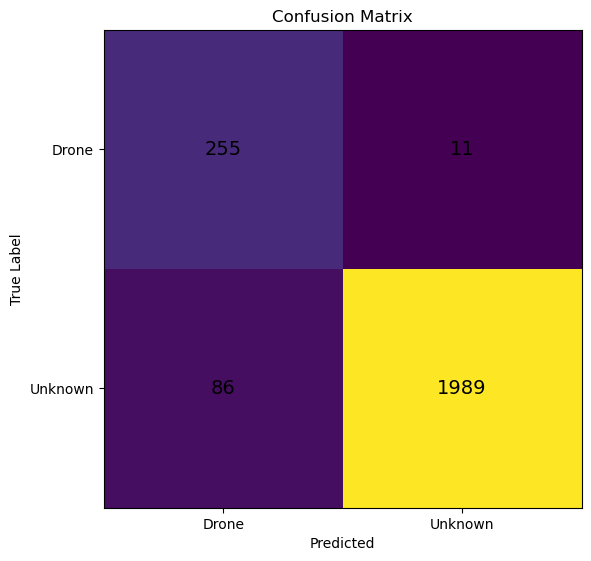

Num features: 143
Num coeffs:   143


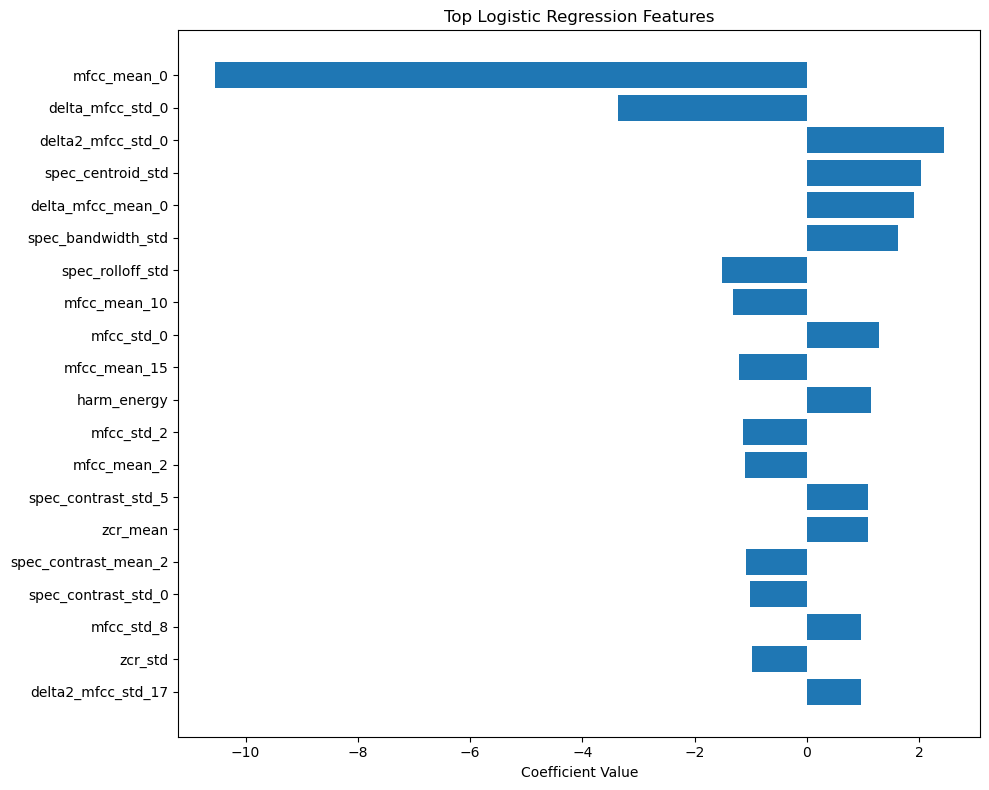

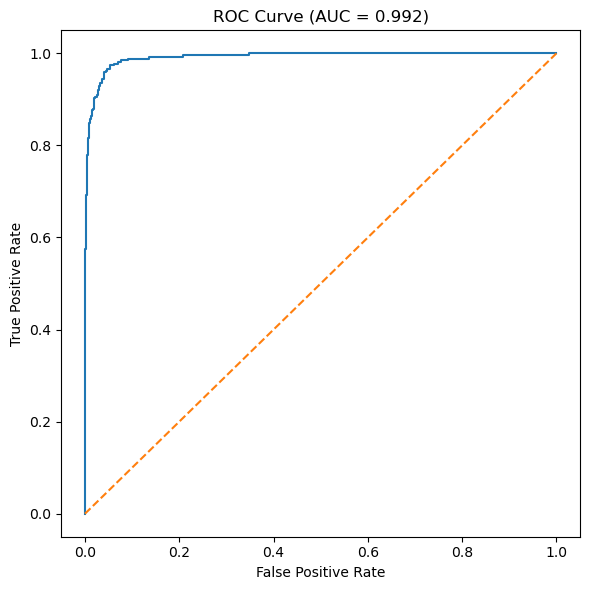

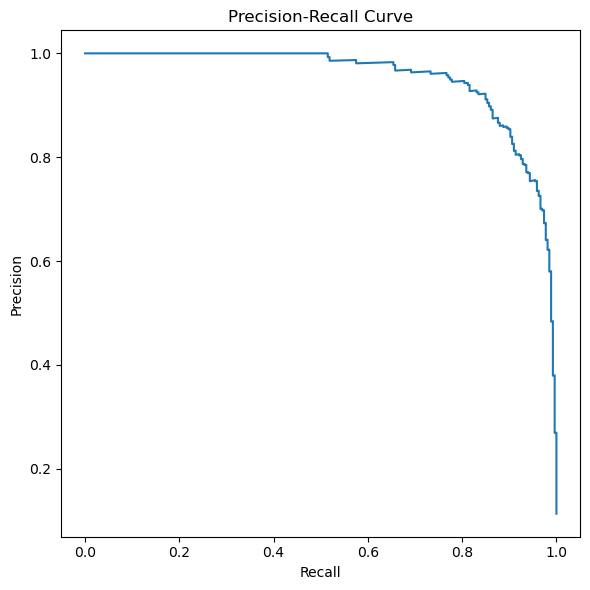

In [13]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve
)

cm = metrics["confusion_matrix"]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Drone", "Unknown"])
ax.set_yticklabels(["Drone", "Unknown"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
            ha="center", va="center", fontsize=14)
        
plt.tight_layout()
plt.show()



classifier = model.named_steps["classifier"]

coeffs = classifier.coef_[0]

feature_names = []

for i in range(20):
    feature_names.append(f"mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta_mfcc_std_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_mean_{i}")

for i in range(20):
    feature_names.append(f"delta2_mfcc_std_{i}")

feature_names += [
    "spec_centroid_mean",
    "spec_centroid_std",
    "spec_bandwidth_mean",
    "spec_bandwidth_std",
    "spec_rolloff_mean",
    "spec_rolloff_std",
]

for i in range(7):
    feature_names.append(f"spec_contrast_mean_{i}")

for i in range(7):
    feature_names.append(f"spec_contrast_std_{i}")

feature_names += ["harm_energy"]

feature_names += ["zcr_mean", "zcr_std"]

print("Num features:", len(feature_names))
print("Num coeffs:  ", len(coeffs))

importance = np.abs(coeffs)
top_n = 20
top_idx = np.argsort(importance)[-top_n:]
top_features = [feature_names[i] for i in top_idx]
top_values = coeffs[top_idx]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features, top_values)
ax.set_title("Top Logistic Regression Features")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

drone_probs = model.predict_proba(X_test)[:, 0]
drone_true = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(drone_true, drone_probs)
roc_auc = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.tight_layout()
plt.show()


precision, recall, _ = precision_recall_curve(
    drone_true, drone_probs)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(recall, precision)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

This is quite good, but with a high false positive rate. First, lets just look and see if changing the threshold works.

In [14]:
drone_probs = model.predict_proba(X_test)[:, 0]

threshold = 0.75

y_pred = (drone_probs > threshold).astype(int)

# class 0 = drone
# convert properly
y_pred = np.where(drone_probs > threshold, 0, 1)

In [15]:
drone_true = (y_test == 0).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),

    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        y_pred
    ),

    "drone_precision": precision_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_recall": recall_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_f1": f1_score(
        y_test,
        y_pred,
        pos_label=0,
        zero_division=0
    ),

    "drone_pr_auc": average_precision_score(
        drone_true,
        y_probs
    ),

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )
}

In [16]:
print("\n metrics")

for key, value in metrics.items():

    if key == "confusion_matrix":
        continue

    print(f"{key}: {value:.4f}")

print("\nConfusion Matrix:")
print(metrics["confusion_matrix"])

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


 metrics
accuracy: 0.9714
balanced_accuracy: 0.9396
drone_precision: 0.8566
drone_recall: 0.8985
drone_f1: 0.8771
drone_pr_auc: 0.9533

Confusion Matrix:
[[ 239   27]
 [  40 2035]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       266
           1       0.99      0.98      0.98      2075

    accuracy                           0.97      2341
   macro avg       0.92      0.94      0.93      2341
weighted avg       0.97      0.97      0.97      2341



In [ ]:
import glob 
import os

import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import numpy as np  
import scipy as sp
from scipy.io import wavfile
from scipy.fft import fft, ifft, fftfreq, rfft, rfftfreq
from scipy.signal import find_peaks
import librosa, librosa.display
import torch
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from tqdm.notebook import tqdm

In [ ]:
#file loading consts
DIR_BASE = '/Users/calvinhinkle/Desktop/school/mines/2026/spring/adML/finalProj/Binary_Drone_Audio/'
DIR_DRONE = os.path.join(DIR_BASE, 'yes_drone')
DIR_UNKNOWN = os.path.join(DIR_BASE, 'unknown')
#feature extraction consts
DURATION = 1.024 #sec
SR = 16000
NUM_FREQUENCIES = int(SR / 2)
LENGTH_N = int(SR * DURATION) #samples
N_FFT = int(1024)
HOP_LENGTH = int(N_FFT / 4)
#ml consts


## Load data

In [ ]:
def fix_length(y, target_len):
    if len(y) > target_len:
        return y[:target_len]
    else:
        return np.pad(y, (0, target_len-len(y)))
    
def preprocess(path):
    yRaw, _ = librosa.load(path, mono=True, sr=SR)
    yNorm = librosa.util.normalize(yRaw)
    y = fix_length(yNorm, LENGTH_N)
    return y

def extract_features(y, sr=SR):
    features = []

    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH))

    # mffcs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # spectral features
    spec_centroid = librosa.feature.spectral_centroid(S=S, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(S=S, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(S=S, sr=sr)
    spec_contrast = librosa.feature.spectral_contrast(S=S, sr=sr)

    for f in [spec_centroid, spec_bandwidth, spec_rolloff]:
        features.append(np.mean(f))
        features.append(np.std(f))

    features.extend(np.mean(spec_contrast, axis=1))
    features.extend(np.std(spec_contrast, axis=1))

    # harmonic and percusive 
    y_harm, y_perc = librosa.effects.hpss(y)

    harm_energy = np.sum(y_harm**2)
    perc_energy = np.sum(y_perc**2)

    features.append(harm_energy)
    features.append(perc_energy)

    # sero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # chromagrams
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features.extend(np.mean(chroma, axis=1))
    features.extend(np.std(chroma, axis=1))

    #features = np.log1p(features)
    return features

#xa - changed to librosa data loading 
def wav_to_data(filepath):
    data = preprocess(filepath)
    if data.ndim > 1:
        data = data.mean(axis=1)
        
    #data = data - np.mean(data)
    features = extract_features(data)
    return features

In [ ]:
def load_dataset(dir_drone, dir_unknown):
    X = []
    y = []
    for label, folder in [(0, dir_drone), (1, dir_unknown)]:
        for filename in os.listdir(folder):
            if not filename.lower().endswith(".wav"):
                continue
            filepath = os.path.join(folder, filename)
            try:
                features = wav_to_data(filepath)
                X.append(features)
                y.append(label)
            except Exception as e:
                print(f"Skipping {filepath}: {e}")
    X = np.stack(X)
    y = np.array(y, dtype=np.int64)
    return X, y

In [ ]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_labels = []
    all_drone_probs = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            test_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(logits, dim=1)
            drone_probs = probs[:, 0]
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y_batch.cpu())
            all_drone_probs.append(drone_probs.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_drone_probs = torch.cat(all_drone_probs).numpy()
    avg_loss = test_loss / len(test_loader.dataset)
    drone_true = (all_labels == 0).astype(int)
    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "balanced_accuracy": balanced_accuracy_score(all_labels, all_preds),
        "drone_precision": precision_score(
            all_labels, all_preds, pos_label=0, zero_division=0
        ),
        "drone_recall": recall_score(
            all_labels, all_preds, pos_label=0, zero_division=0
        ),
        "drone_f1": f1_score(all_labels, all_preds, pos_label=0, zero_division=0),
        "drone_pr_auc": average_precision_score(drone_true, all_drone_probs),
        "confusion_matrix": confusion_matrix(all_labels, all_preds, labels=[0, 1]),
    }
    return metrics

## Model Def

In [ ]:
class NeuralNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(NUM_FREQUENCIES - 1, 2**12),
            torch.nn.ReLU(),
            torch.nn.Linear(2**12, 2**9),
            torch.nn.ReLU(),
            torch.nn.Linear(2**9, 2**6),
            torch.nn.ReLU(),
            torch.nn.Linear(2**6, 2**3),
            torch.nn.ReLU(),
            torch.nn.Linear(2**3, 2),
        )

    def forward(self, x):
        return self.network(x)

## Model

In [ ]:
LEARNING_RATE = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2**8
MAX_NUM_EPOCHS = 2**8
TRAIN_CONVERGE_WINDOW = 2**4
TRAIN_CONVERGE_STD = 0.001
TEST_FRAC = 0.2
RANDOM_SEED = 42
NUM_WORKERS = 10 #10
PIN_MEMORY = True

In [ ]:
X, y = load_dataset(dir_drone=DIR_DRONE, dir_unknown=DIR_UNKNOWN)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)
dataset = TensorDataset(X, y)

In [ ]:
X_np, y_np = load_dataset(dir_drone=DIR_DRONE, dir_unknown=DIR_UNKNOWN)
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=TEST_FRAC, random_state=RANDOM_SEED, stratify=y_np
)
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)
)
# y_train_tensor = torch.tensor(y_train, dtype=torch.long)
# class_counts = torch.bincount(y_train_tensor)
# class_weights = 1.0 / class_counts.float()
# sample_weights = class_weights[y_train_tensor]
# train_sampler = WeightedRandomSampler(
#     weights=sample_weights, num_samples=len(sample_weights), replacement=True
# )
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    shuffle=False,
)

In [ ]:
model = NeuralNet().to(DEVICE)
train_labels = torch.tensor(
    [train_dataset[i][1].item() for i in range(len(train_dataset))]
)
class_counts = torch.bincount(train_labels, minlength=2)
loss_class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
criterion = torch.nn.CrossEntropyLoss(weight=loss_class_weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## train

In [ ]:
plot_data = {
    "epoch": np.array([0.0]),
    "train_loss": np.array([1.0]),
    "test_loss": np.array([1.0]),
    "accuracy": np.array([0.0]),
    "balanced_accuracy": np.array([0.0]),
    "precision": np.array([0.0]),
    "recall": np.array([0.0]),
    "f1-score": np.array([0.0]),
    "pr-auc": np.array([0.0]),
}
for epoch in range(MAX_NUM_EPOCHS):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in tqdm(train_loader):
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    avg_train_loss = total_loss / len(train_loader.dataset)

    metrics = evaluate_model(
        model=model, test_loader=test_loader, criterion=criterion, device=DEVICE
    )
    plot_data["epoch"] = np.append(plot_data["epoch"], epoch + 1)
    plot_data["train_loss"] = np.append(plot_data["train_loss"], avg_train_loss)
    plot_data["test_loss"] = np.append(plot_data["test_loss"], metrics["loss"])
    plot_data["accuracy"] = np.append(plot_data["accuracy"], metrics["accuracy"])
    plot_data["balanced_accuracy"] = np.append(
        plot_data["balanced_accuracy"], metrics["balanced_accuracy"]
    )
    plot_data["precision"] = np.append(
        plot_data["precision"], metrics["drone_precision"]
    )
    plot_data["recall"] = np.append(plot_data["recall"], metrics["drone_recall"])
    plot_data["f1-score"] = np.append(plot_data["f1-score"], metrics["drone_f1"])
    plot_data["pr-auc"] = np.append(plot_data["pr-auc"], metrics["drone_pr_auc"])

    print(
        f'Epoch {str(int(plot_data["epoch"][-1])).rjust(len(str(MAX_NUM_EPOCHS)))}/{MAX_NUM_EPOCHS}  |  '
        f'Train loss: {plot_data["train_loss"][-1]:.4f}  |  '
        f'Test loss: {plot_data["test_loss"][-1]:.4f}  |  '
        f'Acc: {plot_data["accuracy"][-1]:.4f}  |  '
        f'Bal acc: {plot_data["balanced_accuracy"][-1]:.4f}  |  '
        f'Prec: {plot_data["precision"][-1]:.4f}  |  '
        f'Rec: {plot_data["recall"][-1]:.4f}  |  '
        f'F1: {plot_data["f1-score"][-1]:.4f}  |  '
        f'PR-AUC: {plot_data["pr-auc"][-1]:.4f}'
    )
    if len(plot_data["balanced_accuracy"]) > 2 * TRAIN_CONVERGE_WINDOW:
        train_converge_std = plot_data["balanced_accuracy"][
            len(plot_data["balanced_accuracy"]) - TRAIN_CONVERGE_WINDOW :
        ].std()
        if train_converge_std < TRAIN_CONVERGE_STD:
            print("Balanced Accuracy STD Converged:", train_converge_std)
            break

## Plot

In [ ]:
plt.figure(figsize=(16, 9))
plt.plot(plot_data["epoch"], plot_data["train_loss"], ".-", label="Train Loss")
plt.plot(plot_data["epoch"], plot_data["test_loss"], ".-", label="Test Loss")
# plt.plot(plot_data["epoch"], plot_data["accuracy"], ".-", label="Accuracy")
plt.plot(
    plot_data["epoch"], plot_data["balanced_accuracy"], ".-", label="Balanced Accuracy"
)
plt.plot(plot_data["epoch"], plot_data["precision"], ".-", label="Precision")
plt.plot(plot_data["epoch"], plot_data["recall"], ".-", label="Recall")
plt.plot(plot_data["epoch"], plot_data["f1-score"], ".-", label="F1 Score")
# plt.plot(plot_data["epoch"], plot_data["pr-auc"], ".-", label="Average Precision")
plt.xlim([0, len(plot_data["epoch"])])
plt.ylim([0, 1])
plt.xticks(np.append(np.arange(0, len(plot_data["epoch"]), 5), plot_data["epoch"][-1]))
plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.legend() 
plt.grid()
plt.title("Neural Network Training Results")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()
plt.close()